# **Data 300 Final Project**

### Zach Deitch, Yuquing Wang, & Andrew Kelley

In [ ]:
## Cell for correct formatting
import requests
from IPython.core.display import HTML
styles = requests.get("https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/cs109.css").text
HTML(styles)

# **Introduction:**

This project is centered on predicting the continuous and numerical value of Calorie Burn using the 20,000-row Smart Fitness & Nutrition Analytics Dataset (Kaggle; provided by Shahad Aslam). Each observation provides a comprehensive snapshot of a single workout, integrating the physical attributes of the person (such as age, sex, and BMI), workout-specific information (like duration), and pre-workout nutritional details (including water intake). In the end, the resulting model will be employed to forecast the expected caloric expenditure for new, unseen fitness profiles and workout scenarios.

link to the Dataset:
https://www.kaggle.com/datasets/zeesolver/final-dataset/data/code

## **The Fitness Dataset**

The **Fitness dataset** contains information on **detailed personal, nutritional,
 and fitness-related data for 20,000 individuals**.

- **Observations (rows):** 20,000 people
- **Variables (columns):** 54 descriptive and numerical features

### **Key Variables (column names Alted)**


## Column Descriptions

### Numeric Columns:

* **Calories_Burned** - The number of calories burned during the workout (***Target Variable***)
* **Age** - The age of the person (in years)
* **Weight (kg)** - Weight of the person (in kilograms)
* **Height (m)** - Height of the person (in meters)
* **Max_BPM** - The highest heart rate in BPM (beats per minute) achieved during the workout session
* **Avg_BPM** - Average heart rate during the workout session (beats per minute)
* **Resting_BPM** - The person's resting heart rate in BPM
* **Session Duration (hours)** - How long the workout lasted (in hours)
* **Fat_Percentage** - Percent body fat
* **Water_intake (liters)** - Liters of water consumed per day
* **Workout frequency (days/week)** - How many days per week the person works out
* **BMI** - Body mass index, from an external measurement
* **Daily Meals Frequency** - The frequency at which the person has meals
* **Physical exercise** - Scale for the duration of daily activity
* **Carbs** - Daily carb intake (in grams)
* **Proteins** - Daily protein intake (in grams)
* **Fats** - Daily fat intake (in grams)
* **Calories** - Daily calorie intake (in grams)
* **sugar_g** - Nutrient count of sugar in the meal (in grams)
* **sodium_mg** - Nutrient count of sodium in the meal (in milligrams)
* **cholesterol_mg** - Nutrient count of cholesterol in the meal (in milligrams)
* **serving_size_mg** - Serving size of the meal (in milligrams)
* **prep_time_min** - Number of minutes it took to prepare the meal
* **cook_time_min** - Number of minutes it took to cook the meal
* **rating** - A personal satisfaction score for the meal, rated on a 1–5 scale
* **Sets** - Number of workout sets
* **Reps** - Number of workout reps
* **Burns Calories (per 30 min)** - Calculated estimate of how many calories the exercise burns every thirty minutes
* **BMI_calc** - Calculated BMI based on the weight and height variables from the dataset
* **cal_from_macros** - Total estimated calories consumed, calculated from macronutrient composition
* **pct_carbs** - The proportion of total calories in the meal that come from carbohydrates
* **protein_per_kg** - Grams of protein consumed per kilogram of body weight for that meal
* **pct_HHR** - Percentage of heart rate reserve used during the exercise (intensity indicator)
* **pct_maxHR** - How hard someone's heart is working compared to their maximum possible rate
* **cal_balance** - The difference between total calorie intake (pre-workout meal) and calories burned
* **lean_mass_kg** - How much of the person's body is made up of non-fat tissue (in kilograms)
* **expected_burn** - Estimated number of calories burned based on body weight, intensity, duration, and exercise type
* **Burns Calories (per 30 min)_bc** - Calculated estimate of calories burned every thirty minutes, adjusted for the person


### Categorical Columns:

* **Gender** - Biological gender of the person (`male`, `female`)
* **Workout Type** - General category of the training session (`Cardio`, `HIIT`, `Strength`, `Yoga`)
* **Experience_Level** - A personal measure of experience with the exercise, (`Beginner`, `Intermediate`, `Advanced`)
* **meal_name** - Name of the meal the person ate prior to workout, (in the dataset all filled with `other`)
* **Meal Type** - Time of day or classification of the meal ( `Breakfast`, `Lunch`, `Snack`, `Dinner`)
* **cooking_method** - The method used to cook the meal: `Grilled`, `Fried`, `Boiled`, `Baked`, `Steamed`, `Raw`, or `Roasted`
* **Diet Type** - User's dietary specialization or eating plan: `Balanced`,`Low-Carb`,`Vegetarian`,`Keto`, `Vegan`, `Paleo`
* **Name of Exercise** - Categorical variable representing the name of the exercise (55 unique values)
* **Benefit** - Indication of how the exercise benefits the person (49 unique values)
* **Target Muscle Group** - The main muscle groups targeted by the exercise (36 unique values)
* **Equipment Needed** - Required equipment for the exercise e.g., Dumbbells (20 unique values)
* **Difficulty Level** - Perceived difficulty of the exercise (`Beginner`, `Intermediate`,` Advanced`)
* **Body part** - General body part worked (e.g., Leg, Chest)
* **Type of Muscle** - The specific name of the muscle being worked out,e.g., `Lats`, `Wrist flexors` (13 unique values)
* **Workout** - Name of the workout (53 unique values)
* **Burns_Calories_Bin** - Categorical variable grouping the calories burned into ranges (`low`, `medium`, `high`)




## **Loading and Exploring the Fitness Dataset**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Path to the raw CSV file on GitHub
data_path = "https://raw.githubusercontent.com/DickForrester/Data300F2025/main/fitness_nutri.csv"
fitness_df = pd.read_csv(data_path)
print("Shape of dataframe: "+str(fitness_df.shape)+ '\n')
fitness_df.info()

Shape of dataframe: (20000, 54)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  float64
 1   Gender                          20000 non-null  object 
 2   Weight (kg)                     20000 non-null  float64
 3   Height (m)                      20000 non-null  float64
 4   Max_BPM                         20000 non-null  float64
 5   Avg_BPM                         20000 non-null  float64
 6   Resting_BPM                     20000 non-null  float64
 7   Session_Duration (hours)        20000 non-null  float64
 8   Calories_Burned                 20000 non-null  float64
 9   Workout_Type                    20000 non-null  object 
 10  Fat_Percentage                  20000 non-null  float64
 11  Water_Intake (liters)           20000 non-null  float64
 12 

## Classification or Regression?

Given that our project goal is to predict value of calories burned within specific scenarios, this task is a regression problem. We anticipate that not all variables within the dataset will contribute meaningfully to the predictive power of the model. Therefore, we will use EDA to accomplish data structure inspection, data cleaning, and visualization of distributions before fitting the final model.


**Checking for missing values and change data type:**

In [ ]:
fitness_df.isna().sum() #There appear to be no missing values in the dataset.

for col in fitness_df.columns:
  if fitness_df[col].dtype == 'object':
    fitness_df[col]=fitness_df[col].astype('category')

fitness_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Age                             20000 non-null  float64 
 1   Gender                          20000 non-null  category
 2   Weight (kg)                     20000 non-null  float64 
 3   Height (m)                      20000 non-null  float64 
 4   Max_BPM                         20000 non-null  float64 
 5   Avg_BPM                         20000 non-null  float64 
 6   Resting_BPM                     20000 non-null  float64 
 7   Session_Duration (hours)        20000 non-null  float64 
 8   Calories_Burned                 20000 non-null  float64 
 9   Workout_Type                    20000 non-null  category
 10  Fat_Percentage                  20000 non-null  float64 
 11  Water_Intake (liters)           20000 non-null  float64 
 12  Workout_Frequency 

**Variable Name Standardization**


We notice some inconsistence in variable naming.(e.g, some variables starts with capitals while some starts with lowercase letter) and more than 1 character in one variable name (not wrong, but can be confusing). Below is the altered variable names with same capitalization and with only character `_`.



In [ ]:
print("Columns before transformation:\n\n ", fitness_df.columns)
fitness_df.columns = fitness_df.columns.str.strip().str.lower().str.replace(' ','_').str.replace('(','_').str.replace(')','_').str.strip('_').str.replace('__', '_')
print('\n\n')
fitness_df = fitness_df.rename(columns={'workout_frequency_days/week': 'workout_frequency_day_per_week'})
print("Columns after transformation:\n\n ", fitness_df.columns)

Columns before transformation:

  Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI',
       'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins',
       'Fats', 'Calories', 'meal_name', 'meal_type', 'diet_type', 'sugar_g',
       'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'cooking_method',
       'prep_time_min', 'cook_time_min', 'rating', 'Name of Exercise', 'Sets',
       'Reps', 'Benefit', 'Burns Calories (per 30 min)', 'Target Muscle Group',
       'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle',
       'Workout', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg',
       'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn',
       'Burns Calories (per 30 min)_bc', 'Burns_Calories_Bin'],
    

**The code cell below is to see the summary statistics for the quantitative variables and categorical variables seperately**

In [ ]:
# Set the number of decimals to display
pd.set_option("display.precision", 2)

# Print the summary statistics (of the quantitative vaiables)
print("=== Quantitative Variables Summary ===")
fitness_df.describe()


# Show a summary of all categorical variables
print("=== Categorical Variables Summary ===")

# Loop through each categ corical column in the dataframe
categorical_columns = fitness_df.select_dtypes("category").columns

for column in categorical_columns:
    # Count how many unique values this column has
    num_unique = fitness_df[column].nunique()

    print(f"\n{column} (Unique values = {num_unique})")
    # Show frequency counts of each category
    print(fitness_df[column].value_counts())

=== Quantitative Variables Summary ===
=== Categorical Variables Summary ===

gender (Unique values = 2)
gender
Female    10028
Male       9972
Name: count, dtype: int64

workout_type (Unique values = 4)
workout_type
Strength    5071
Yoga        5032
HIIT        4974
Cardio      4923
Name: count, dtype: int64

meal_name (Unique values = 1)
meal_name
Other    20000
Name: count, dtype: int64

meal_type (Unique values = 4)
meal_type
Lunch        5047
Dinner       5011
Breakfast    4981
Snack        4961
Name: count, dtype: int64

diet_type (Unique values = 6)
diet_type
Paleo         3403
Low-Carb      3379
Vegetarian    3337
Keto          3324
Vegan         3323
Balanced      3234
Name: count, dtype: int64

cooking_method (Unique values = 7)
cooking_method
Baked      2953
Steamed    2921
Raw        2899
Grilled    2827
Roasted    2824
Boiled     2789
Fried      2787
Name: count, dtype: int64

name_of_exercise (Unique values = 55)
name_of_exercise
Flutter Kicks                  412
Deadlif

###**Obvious Outlier**

The burns_calories_per_30_min_bc column might have some outlier values. Let's see how many are above 100000 (already a ridiculous number of calories)

In [ ]:
threshold = 100000
num_outliers = (fitness_df['burns_calories_per_30_min_bc'] > 100000).sum()
print("Number of values above 100000 calories: ", num_outliers)

Number of values above 100000 calories:  20000


This column appears to have inaccurately huge values, and thus is not helpful for our model.

In [ ]:
fitness_df=fitness_df.drop('burns_calories_per_30_min_bc',axis=1) #dropping the burns_calories_per_30_min_bc column

###**Scale and Distribution**
**To check the scale of the data, we will calculate the ranges of each numerical column as well as general distribution of target variable `calories_burned`**

age                                41.670
weight_kg                          91.590
height_m                            0.520
max_bpm                            40.330
avg_bpm                            50.770
resting_bpm                        25.010
session_duration_hours              1.530
calories_burned                  2567.710
fat_percentage                     23.667
water_intake_liters                 2.270
workout_frequency_day_per_week      3.120
experience_level                    2.050
bmi                                38.190
daily_meals_frequency               2.090
physical_exercise                   4.120
carbs                             324.770
proteins                          130.170
fats                               86.830
calories                         2860.000
sugar_g                            51.180
sodium_mg                        2508.050
cholesterol_mg                    307.880
serving_size_g                    411.570
prep_time_min                     

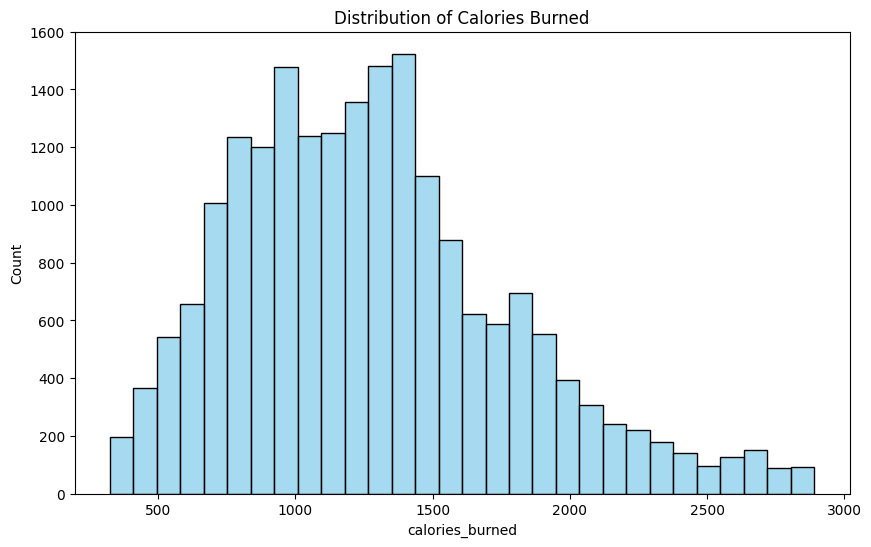

In [ ]:
numeric_cols = fitness_df.select_dtypes(include='number')
ranges = numeric_cols.max() - numeric_cols.min()
print(ranges)

plt.figure(figsize=(10, 6))
sns.histplot(
    data=fitness_df,
    x='calories_burned',
    bins=30,
    color='skyblue'
)
plt.title('Distribution of Calories Burned')
plt.show()

As it turns out, the target variable is slightly right-skewed. Will it be better if we transform it? below is the attempt to us a logarithmic and squared transformations of `Calories_Burned`.

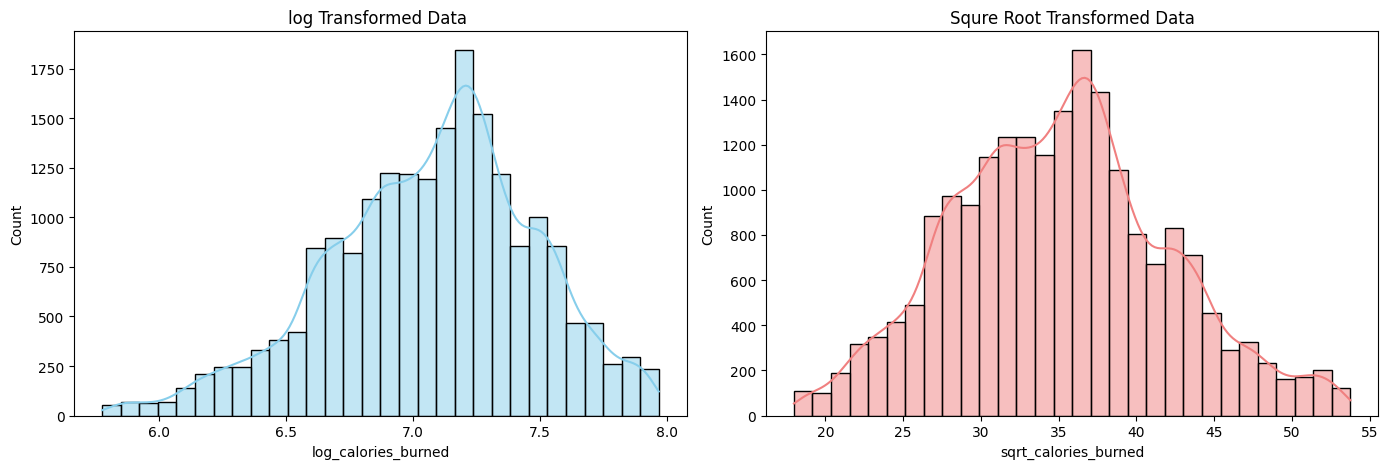

In [ ]:
fitness_df['log_calories_burned'] = np.log(fitness_df['calories_burned'])
fitness_df['sqrt_calories_burned'] = np.sqrt(fitness_df['calories_burned'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(
    data=fitness_df,
    x='log_calories_burned',
    bins=30,
    color='skyblue',
    kde=True,
    ax=axes[0]
)
axes[0].set_title('log Transformed Data ')

sns.histplot(
    data=fitness_df,
    x='sqrt_calories_burned',
    bins=30,
    color='lightcoral',
    kde=True,
    ax=axes[1]
)
axes[1].set_title('Squre Root Transformed Data')


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Both methods show improvement on normality, but the square-root transformation seems closer to the bell curve shape. We will use the `sqrt_calories_burned` to fit the model later.

#**Exploratory Data Analysis & Feature Engineering**

We see a lot of the variables are about diet. Inuition told us a lot of them are not useful for prediction

   daily_meals_frequency   carbs  proteins   fats  calories meal_name  \
0                  2.990 267.680   106.050 71.630  1806.000     Other   
1                  3.010 214.320    85.410 56.970  1577.000     Other   
2                  1.990 246.040    98.110 65.480  1608.000     Other   

   meal_type   diet_type  sugar_g  sodium_mg  cholesterol_mg  serving_size_g  \
0      Lunch       Vegan   31.770   1729.940         285.050         120.470   
1      Lunch  Vegetarian   12.340    693.080         300.610         109.150   
2  Breakfast       Paleo   42.810   2142.480         215.420         399.430   

  cooking_method  prep_time_min  cook_time_min  rating  cal_from_macros  \
0        Grilled         16.240        110.790   1.310         2139.590   
1          Fried         16.470         12.010   1.920         1711.650   
2         Boiled         54.350          6.090   4.700         1965.920   

   pct_carbs  protein_per_kg  calories_burned  
0      0.500           1.625         

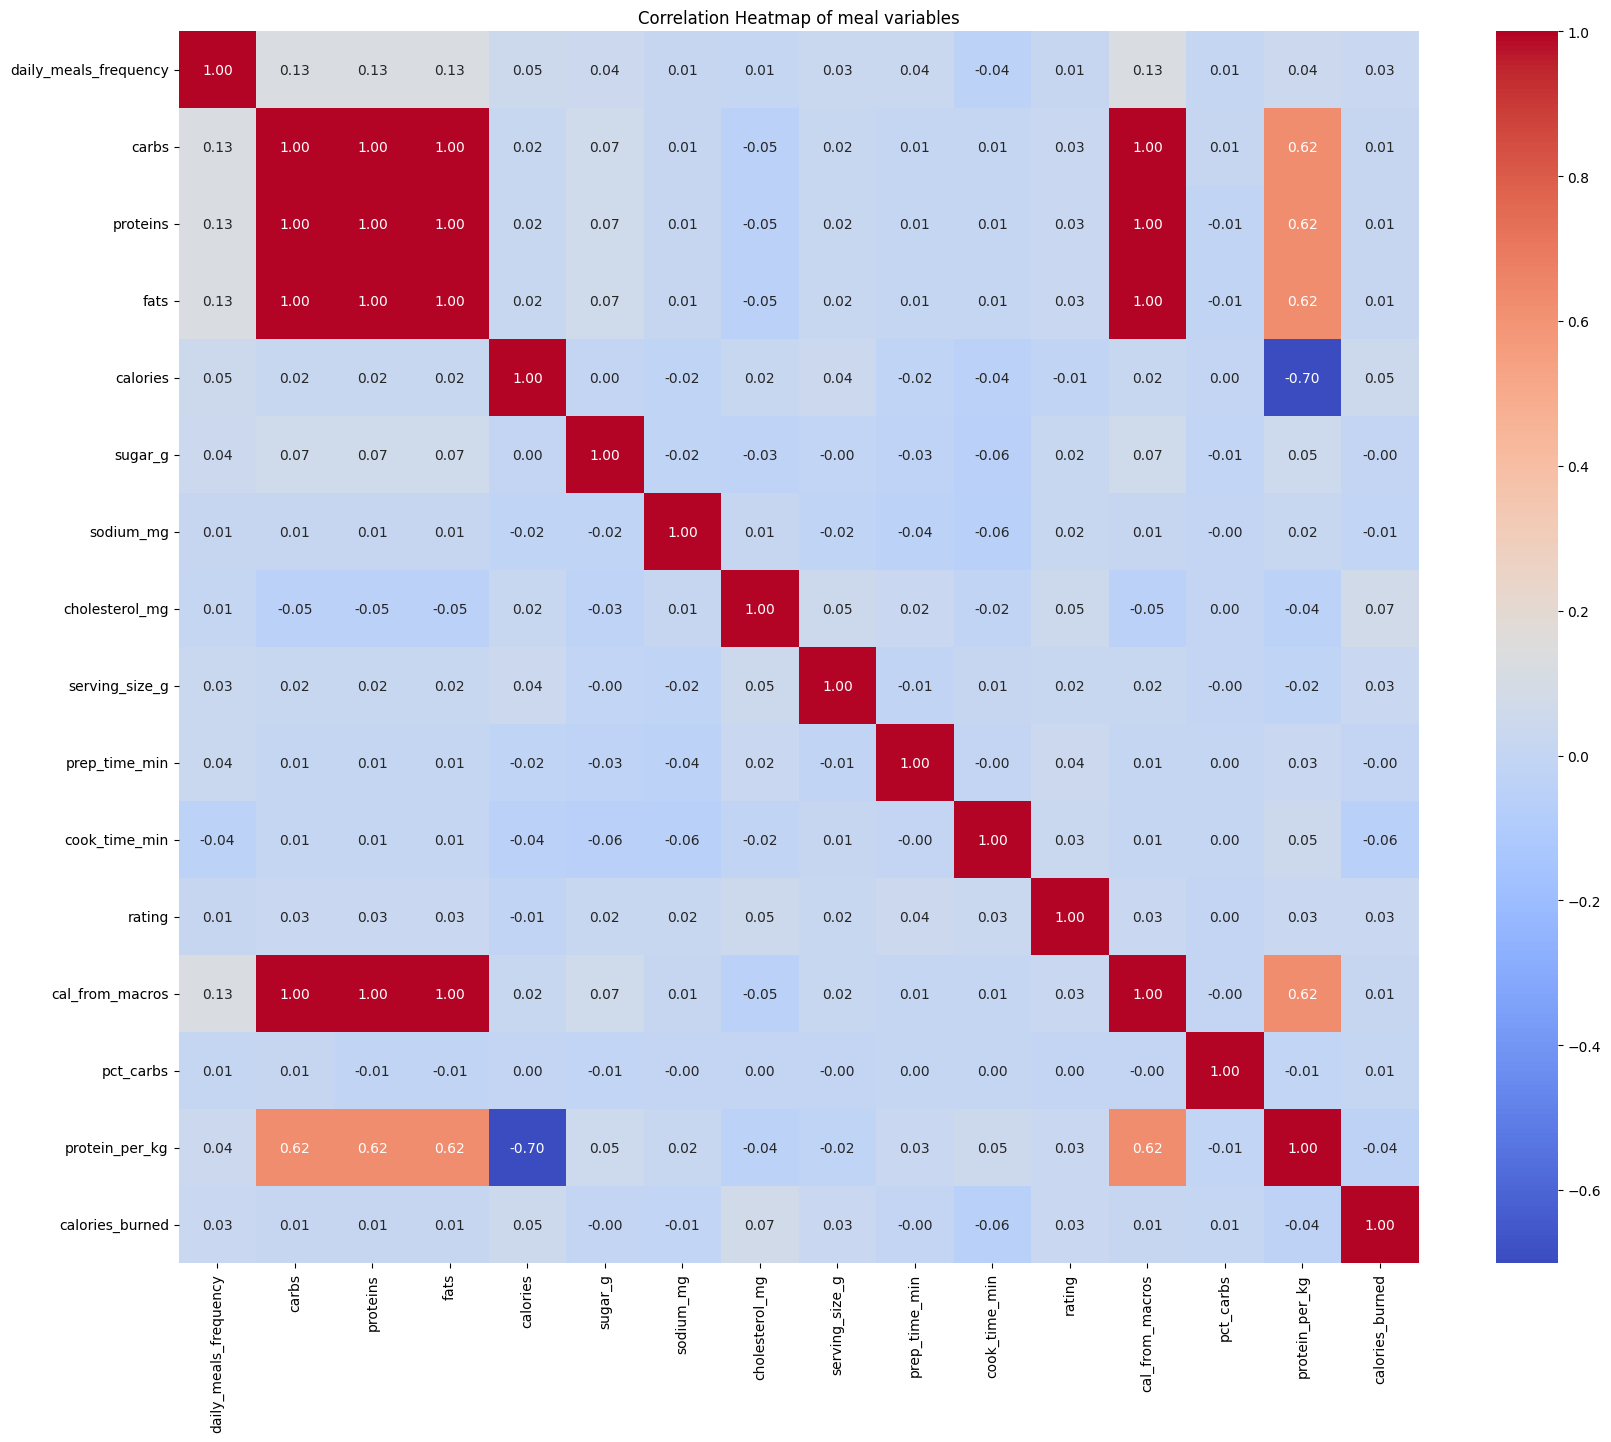

In [ ]:
#meal variables inspection
fit_meal=fitness_df[['daily_meals_frequency', 'carbs', 'proteins', 'fats', 'calories', 'meal_name', 'meal_type', 'diet_type', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'cooking_method', 'prep_time_min', 'cook_time_min', 'rating', 'cal_from_macros', 'pct_carbs', 'protein_per_kg' ,'calories_burned']]
print(fit_meal.head(3))

corr = fit_meal.corr(numeric_only=True)

plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of meal variables")
plt.show()

* in general, none of these varibles have significant linear relationship with the target variable, but we still want to keep some of them.

* a lot of them don't have anything to do with intake just by common sense(e.g, `rating`,`cooking_time_min`),so we are dropping them

*   `caloreis`and `chelestrol_mg` has the hightest correlation with targer variable, so we might want to keep them




In [ ]:
#inspect the categorical variables
fit_exercise_categorical = fitness_df.select_dtypes(include="category")

unique_counts = fit_exercise_categorical.nunique().sort_values(ascending=False)
print(unique_counts)
print(fit_exercise_categorical.head(3))

name_of_exercise       55
workout                53
benefit                49
target_muscle_group    36
equipment_needed       20
type_of_muscle         13
cooking_method          7
body_part               7
diet_type               6
meal_type               4
workout_type            4
burns_calories_bin      4
difficulty_level        3
gender                  2
meal_name               1
dtype: int64
   gender workout_type meal_name  meal_type   diet_type cooking_method  \
0    Male     Strength     Other      Lunch       Vegan        Grilled   
1  Female         HIIT     Other      Lunch  Vegetarian          Fried   
2  Female       Cardio     Other  Breakfast       Paleo         Boiled   

   name_of_exercise                               benefit  \
0  Decline Push-ups  Improves shoulder health and posture   
1       Bear Crawls                 Strengthens lower abs   
2              Dips                 Builds chest strength   

     target_muscle_group equipment_needed difficulty_le

we see a lot of the variables are just descriptive text, and has no actual meaning. They are: `name_of_exercise`,`workout`,`benefit`,`target_muscle_group`,`equipment_needed`,`type_of_muscle`. we are getting rid of them too.

Now let's look at the numeric variables

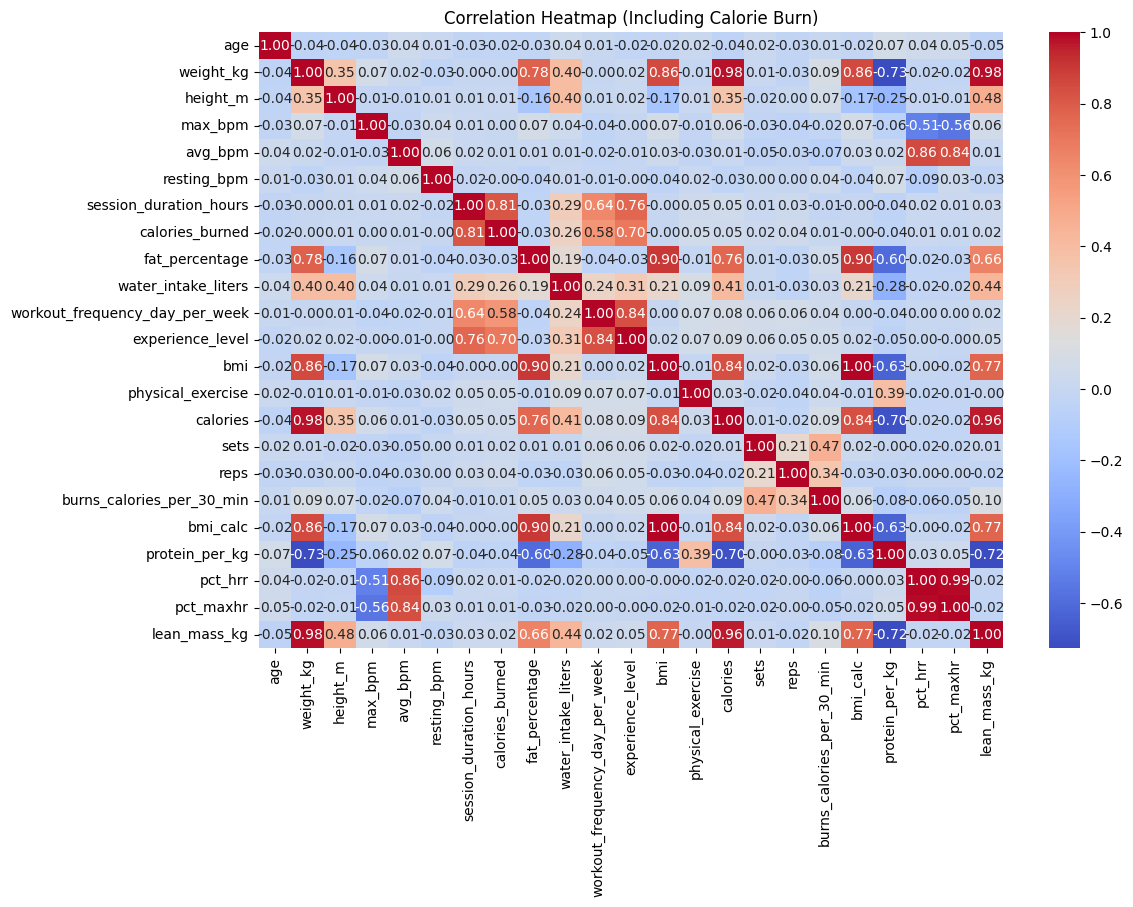

In [ ]:
cols_numeric = ['age', 'weight_kg', 'height_m', 'max_bpm', 'avg_bpm', 'resting_bpm',
'session_duration_hours', 'calories_burned', 'fat_percentage',
'water_intake_liters', 'workout_frequency_day_per_week',
'experience_level', 'bmi', 'physical_exercise', 'calories', 'sets',
'reps', 'burns_calories_per_30_min', 'bmi_calc', 'protein_per_kg',
'pct_hrr', 'pct_maxhr', 'lean_mass_kg']
plt.figure(figsize=(12, 8))
sns.heatmap(fitness_df[cols_numeric].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Including Calorie Burn)")
plt.show()


- The heatmap above shows that there are some clear correlations between calorie burn and certain variables: namely session duration, workout frequency, experience level, water intake, and calorie balance.
- In order to confirm the positive relationship between calorie burn and such variables, and to check for multicollinearity and outliers, we will use other visualization methods.

It would also be beneficial to check the normality of the selected columns.
- A pairplot would accomplish this (by looking at the graphs on the diagonal) while also allowing us to visualize the plots between other variables

<Figure size 1400x1000 with 0 Axes>

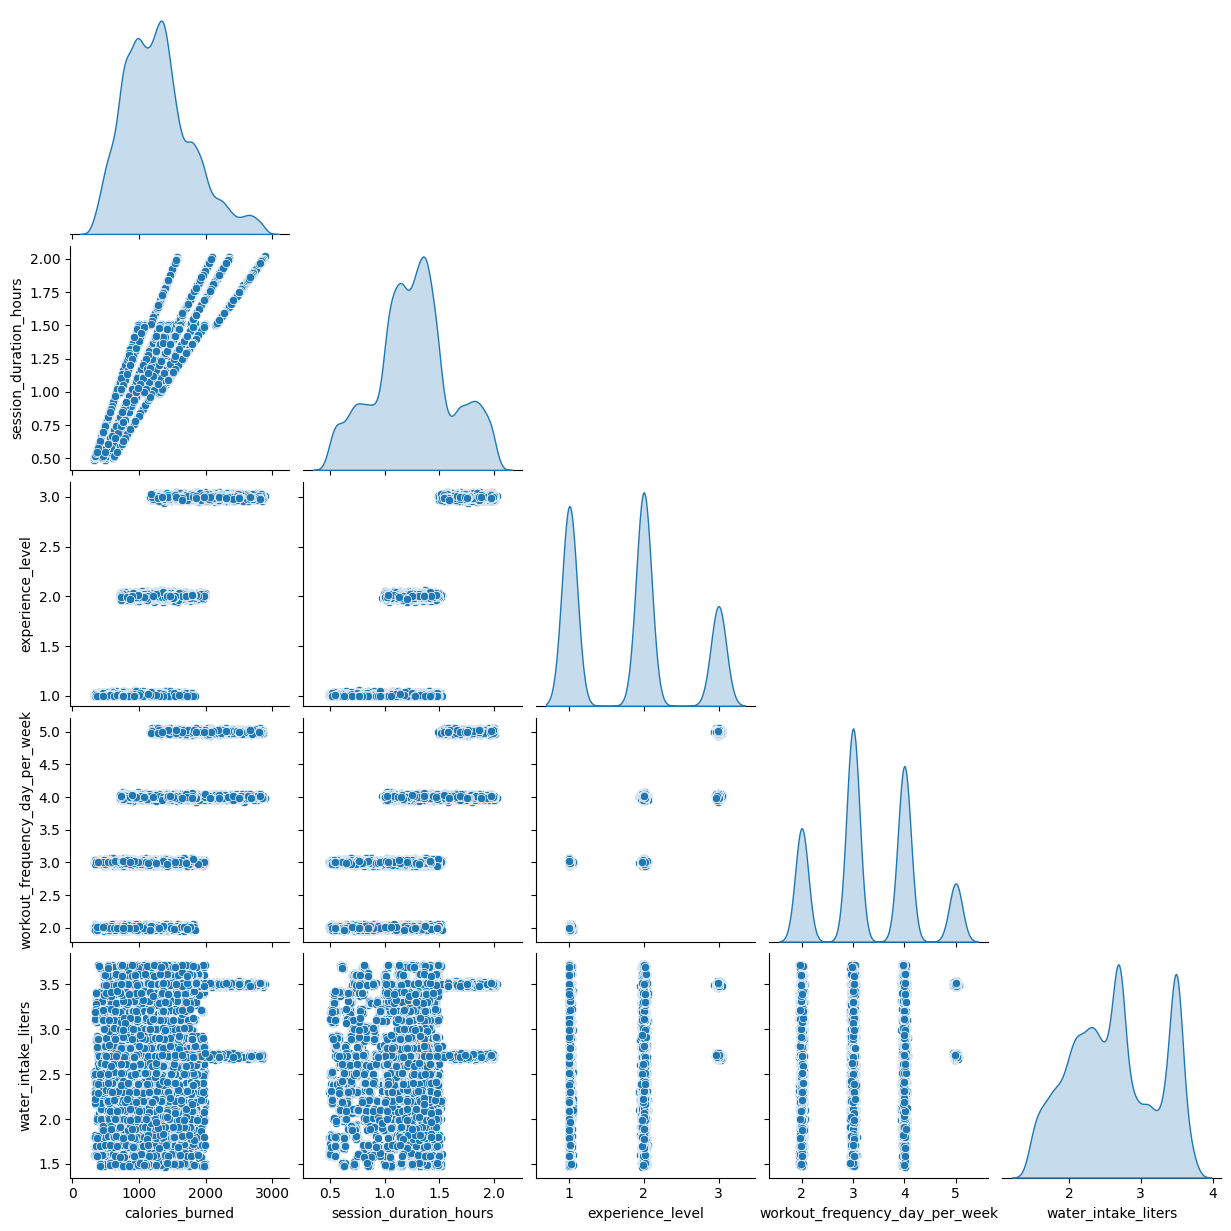

In [ ]:
top_corr_cols = ["calories_burned", "session_duration_hours",
                 "experience_level", "workout_frequency_day_per_week",
                "water_intake_liters"]

df_top = fitness_df[top_corr_cols]

plt.figure(figsize=(14, 10))
sns.pairplot(df_top, diag_kind="kde", corner=True)
plt.show()

- The variables that are continuous seem normally distributed, and there does seem to be a lot of correlation between the variables
- For example, Workout frequency very clearly increases with experience level.


Now we will check for outliers and further examine individual plots
- Session duration and the person's experience level with the workout might play a large role in calorie burn.
- As shown below, the experience level and workout frequency columns contain some values that are fractional, but extremely close to one of the main levels (1,2,3). We round these columns to simplify analysis and interpretation.
- Below is a scatterplot of calorie burn vs session duration.
- Additionally, we will generate boxplots of experience level to check for skewness and outliers.



In [ ]:
fitness_df['workout_frequency_day_per_week_whole']=fitness_df['workout_frequency_day_per_week'].round()


In [ ]:
fitness_df['experience_level_whole']=fitness_df['experience_level'].round()

In [ ]:
print(fitness_df['experience_level'].unique())
print(fitness_df['workout_frequency_day_per_week'].unique())

[2.01 1.02 1.99 2.   1.   3.   3.02 2.98 3.01 2.99 1.98 1.95 2.02 2.97
 1.97 1.01 3.03 2.04 1.04 2.96 3.04 1.03 1.94 2.03 1.96 2.95 3.05 2.05
 1.05 2.06 1.06 2.94]
[3.99 4.   2.99 3.02 4.96 3.97 4.01 2.   5.02 5.   3.01 3.   3.98 5.01
 1.99 1.97 5.04 2.96 2.97 2.98 4.97 4.99 3.04 1.98 4.02 2.04 5.03 2.02
 2.01 3.03 3.07 1.96 4.98 4.04 3.05 4.03 3.95 4.06 5.06 2.03 2.95 4.05
 3.96 1.95 3.06 4.95 2.05 2.06 2.94 5.05 4.07 4.94 3.94 1.94 3.93]


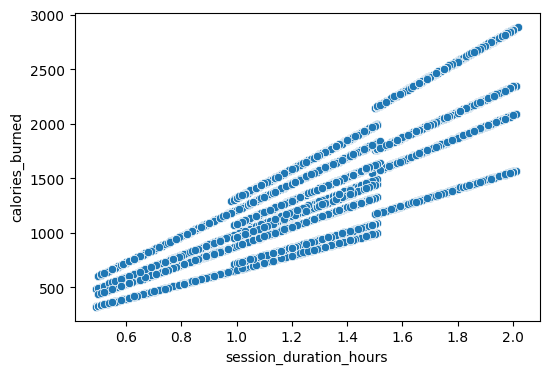

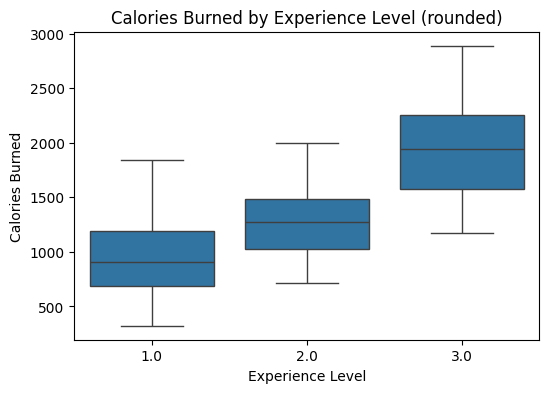

In [ ]:

plt.figure(figsize=(6,4))
sns.scatterplot(data=fitness_df, x="session_duration_hours", y="calories_burned")
plt.figure(figsize=(6,4))
sns.boxplot(data=fitness_df, x="experience_level_whole", y="calories_burned")
plt.title("Calories Burned by Experience Level (rounded)")
plt.xlabel("Experience Level")
plt.ylabel("Calories Burned")
plt.show()

The plots display clear positive trends with no outliers. Interestingly, the scatterplot of calorie burn vs session duration seems "stratified" in a sense - there are almost layered lines of calorie burn, reflecting a variety of different trends.
-  This suggests that maybe there are hidden synergies between duration and other variables that together influence the target.
- Let's try subsetting the scatterplot by experience_level, for example.

<Axes: xlabel='session_duration_hours', ylabel='calories_burned'>

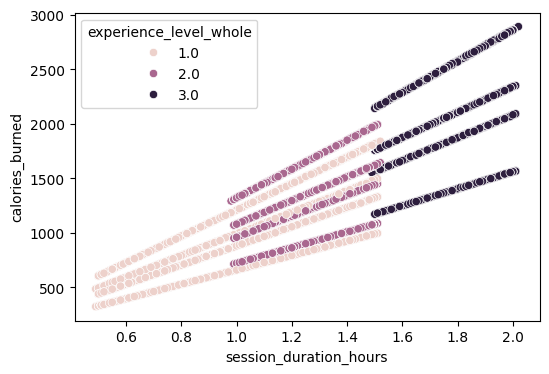

In [ ]:

plt.figure(figsize=(6,4))
sns.scatterplot(data=fitness_df, x="session_duration_hours", y="calories_burned", hue = 'experience_level_whole')



It definitely seems like lines toward the upper-right are occupied by the higher experience levels - people with higher experience levels do burn more calories, but they also do longer workouts. This confirms correlation between duration and experience level, which is important.

- It is also important to note that there seems to be a linear relationship between duration and calories burned.

We can also check the categorical variables relationships, which are not reflected in the heatmap.

- For example, are there differences in calorie burn based on physical traits like gender?

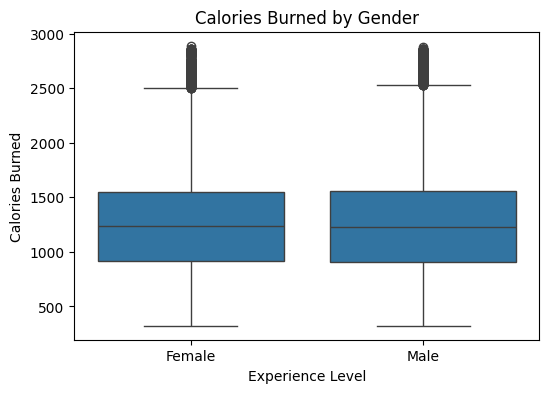

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=fitness_df, x="gender", y="calories_burned")
plt.title("Calories Burned by Gender")
plt.xlabel("Experience Level")
plt.ylabel("Calories Burned")
plt.show()

Gender seems to have no effect on calorie burn.

- We can also plot the effects of details about the workout such as workout category and workout.

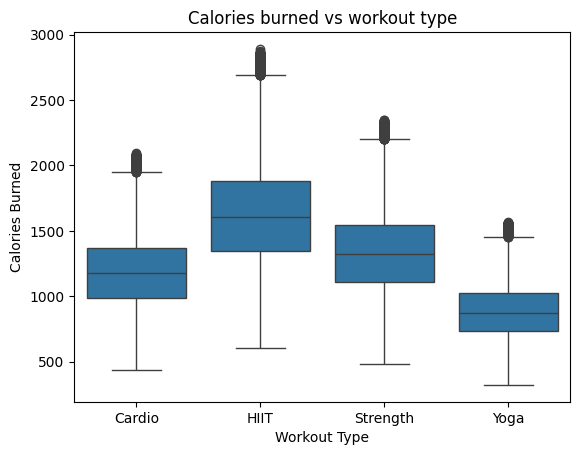

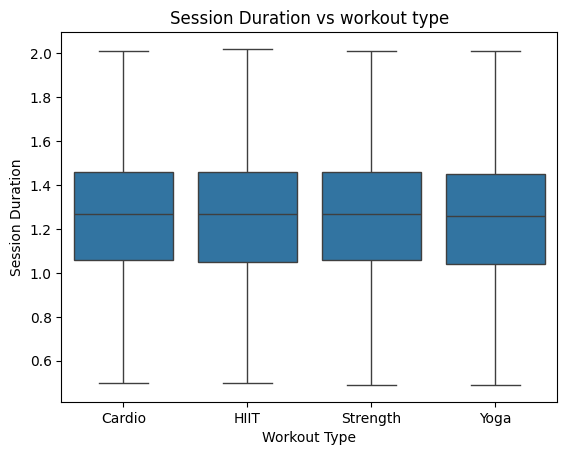

In [ ]:
sns.boxplot(data=fitness_df, x="workout_type", y="calories_burned")
plt.title("Calories burned vs workout type")
plt.xlabel("Workout Type")
plt.ylabel("Calories Burned")
plt.show()




sns.boxplot(data=fitness_df, x="workout_type", y="session_duration_hours")
plt.title("Session Duration vs workout type")
plt.xlabel("Workout Type")
plt.ylabel("Session Duration")
plt.show()


Though there are a considerable number of outliers, the boxplots show a clear ordering: high intensity workouts yield the highest calorie burn, followed by strength, cardio, and yoga.

We also see that session duration does not seem to vary between workout types - indicating workout type contributes *causally* to calorie burn

There is variation in calorie burn from the perspective of the individual exercises as well - the medians take on a range between abut 1100 and 1300.
- However, when plotting median session duration vs the exercises, they are ordered in a similar way - this indicates that some exercises tend to burn more calories mostly because they last longer, making the individual exercises a  redundant predictor.




Lets confirm if the workout type feature explains the stratification in the graph before:

<Axes: xlabel='session_duration_hours', ylabel='calories_burned'>

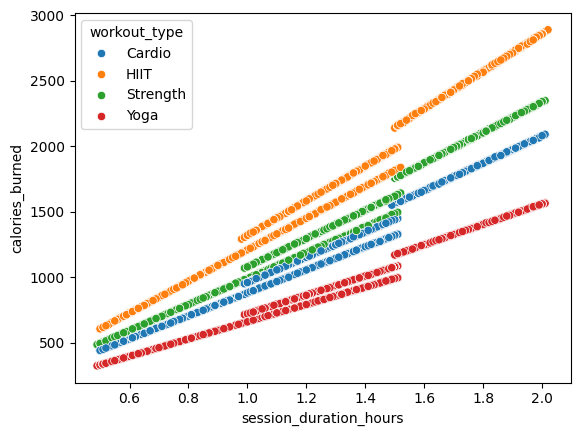

In [ ]:
sns.scatterplot(data=fitness_df, x="session_duration_hours", y="calories_burned", hue = 'workout_type')

Yes - there is clear ordering to the layered lines, as given by these workout types. This suggests that Workout type accounts for some of the variation in calorie burn that session duration can't.

### Feature engineering

To improve model accuracy, we will create new features that capture new aspects of the workout.
*  Intensity Index: there are studies shown that weight-loss/
calories-brurn is more effective in high intensity activitities(BPM reach to a certain speed). also, the effectiveness of calorie consumption is related to how much time spent. Thus, a new feature `Intensity Index`might be helpful.
*  besides, a new feature `sets x reps` might also be helpful, since this feature can roughly approximate the volume of exercise, by including how many actual motions of the exercise the person does. This can hopefully serve as a rough proxy for calorie burn that is somewhat different from duration, since it simulates the amount of energy and movement the person's body is undergoing.
* `duration_x_experience`: we have observed in our prior scatterplot of calorie burn vs session duration that the layered, rotated lines can be accounted by experience level categories, hinting at a possible interaction. By including this feature, the model can change the effect of one predictor based on the level of another, in theory being able to capture that synergy.
* `workout_type_x_duration`: We saw that session duration and workout type were independently contributing to calorie burn. It's very possible that the amount of calories burned over time varies with workout type- different muscles/parts of the body may respond differently based on the length of time they strain. This feature would capture this synergy between time and workout type.
* `volume_per_hour`:  This feature essentially represents the _rate_ at which the person is doing motions of the exercise. It's possible that more rapid volumes of sets and reps could correspond to increased activity, and stand as a time-independent measure of calorie burn, providing a new edge to predictive performance


In [ ]:
fitness_df['Intensity_Index'] = fitness_df['avg_bpm'] * fitness_df['session_duration_hours']
fitness_df['sets_x_reps'] = fitness_df['reps'] * fitness_df['sets']
fitness_df['volume_per_hour'] = fitness_df['sets_x_reps'] / fitness_df['session_duration_hours']
fitness_df['duration_x_experience'] = fitness_df['session_duration_hours'] * fitness_df['experience_level']

# since workout_type is categorical, we will need to do get dummies (one-hot encode) for each category, then multiply by session_duration_hours for the interaction.
dummies = pd.get_dummies(fitness_df["workout_type"], drop_first=True)
for col in dummies.columns:
    dummies[f"duration_x_{col}"] = fitness_df["session_duration_hours"] * dummies[col]

#so there will now be one column for each workout type, with the corresponding value.



##**Initial modeling**|
- In this section, we will build and test different types of models to decide which one to go forward with and tune.


It's important that the model treats columns that are supposed to be categorical as categorical, so we should actually change the type of the experience_level_whole and workout_frequency_days_per_week_whole column to "category"

In [ ]:
fitness_df["experience_level_whole"] = fitness_df["experience_level_whole"].astype("category")
fitness_df["workout_frequency_day_per_week_whole"] = fitness_df["experience_level_whole"].astype("category")

Because our EDA suggested that several predictors had approximately linear relationships with target, we will begin with linear regression. We will use Lasso for regularization and variable selection, and to help mitigate overfitting. Lasso is a principled way to select features, and it should set many to zero. This is appropriate both for the sake of an interpretable baseline, and because we observed in the EDA that some variables did clearly seem to dominate in their predictive power.

First, we want to elimimnate etxra variables from x variables(reasons explained in EDA section)

In [ ]:
X_reg=fitness_df.drop(columns=[
    'daily_meals_frequency',
    'carbs',
    'proteins',
    'fats',
    'meal_name',
    'meal_type',
    'diet_type',
    'sugar_g',
    'sodium_mg',
    'serving_size_g',
    'cooking_method',
    'prep_time_min',
    'cook_time_min',
    'rating',
    'name_of_exercise',
    'benefit',
    'target_muscle_group',
    'equipment_needed',
    'type_of_muscle',
    'workout',
    'cal_from_macros',
    'pct_carbs',
    'protein_per_kg'
])

X_reg = X_reg.drop(columns=["calories_burned", "burns_calories_bin","expected_burn","burns_calories_per_30_min", "cal_balance", "experience_level", "log_calories_burned","sqrt_calories_burned"])
# drop the target variable and columns that are calculated from exact calories_burned (data leakage)
# the continuous experience_level is unnecessary, since experience_level_whole is essentially a replacement that reflects the column's intended categorical nature.

X_reg = X_reg.drop(columns=['bmi_calc','lean_mass_kg'])
#those repeat wih BMI

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_val_predict



y = fitness_df["sqrt_calories_burned"]

print("current x:", X_reg .columns)

# One-hot encode categorical variables
X = pd.get_dummies(X_reg , drop_first=True)

# Standardize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

alphas = np.logspace(-2, 2, 20)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    y_pred_cv = cross_val_predict(lasso, X_scaled, y, cv=kf)
    rmse_scores.append(np.sqrt(mean_squared_error(y, y_pred_cv)))

best_alpha = alphas[np.argmin(rmse_scores)]

lasso = Lasso(alpha=best_alpha, max_iter=10000)
lasso.fit(X_train, y_train)

# Show coefficients
print("Lasso Regression Coefficients:")
coefficients = pd.Series(lasso.coef_, index=X.columns)
pos_coeffs = coefficients[coefficients > 0]
important_coeffs = coefficients[coefficients*coefficients >= 0.1]
print(coefficients.sort_values(key=abs, ascending=False))

#5 fold cross validation
r2_scores = cross_val_score(lasso, X_scaled, y, cv=kf, scoring='r2')
print("mean test R^2: ", np.mean(r2_scores))
y_pred_cv = cross_val_predict(lasso, X_scaled, y, cv=kf)
rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
print("RMSE: ", rmse)

print("Best alpha:", best_alpha)

print("Lasso Regression Coefficients:")
coefficients = pd.Series(lasso.coef_, index=X.columns)


# Gathering the most influential features, and also seeing which ones Lasso set to zero - this will give info about how it selects features.

top_coeffs = coefficients.abs().sort_values(ascending=False).head(20)
zero_coeffs = coefficients[coefficients == 0]

print("\nTop coefficients by absolute value:")
print(top_coeffs)

print("\nCoefficients set exactly to zero:")
zero_coeffs_series = pd.Series(0, index=zero_coeffs.index, name="Coefficient")
zero_coeffs_series



current x: Index(['age', 'gender', 'weight_kg', 'height_m', 'max_bpm', 'avg_bpm',
       'resting_bpm', 'session_duration_hours', 'workout_type',
       'fat_percentage', 'water_intake_liters',
       'workout_frequency_day_per_week', 'bmi', 'physical_exercise',
       'calories', 'cholesterol_mg', 'sets', 'reps', 'difficulty_level',
       'body_part', 'pct_hrr', 'pct_maxhr',
       'workout_frequency_day_per_week_whole', 'experience_level_whole',
       'Intensity_Index', 'sets_x_reps', 'volume_per_hour',
       'duration_x_experience'],
      dtype='object')
Lasso Regression Coefficients:
session_duration_hours                      4.517
workout_type_HIIT                           2.541
workout_type_Yoga                          -1.978
workout_frequency_day_per_week_whole_3.0    0.901
workout_type_Strength                       0.891
volume_per_hour                            -0.632
experience_level_whole_2.0                  0.373
workout_frequency_day_per_week_whole_2.0    0.358
s

,Coefficient
avg_bpm,0
fat_percentage,0
water_intake_liters,0
bmi,0
physical_exercise,0
calories,0
cholesterol_mg,0
reps,0
pct_hrr,0
pct_maxhr,0


1) The mean test R^2 above indicates that the model explains ~99.12% of the variability in the numbers of calories burned after workouts.
- This error metric was chosen for its interpretability of model fit - we know to interpret it as the the total amount of variation of the true data around the model's estimates.
2) The RMSE was 0.65, indicating that on average, the model's prediction was off by 0.65 units (square-rooted calories). This is also quite good considering the scale of sqrt_calories_burned, which has a median of about 35.
- This metric was chosen because it is very interpretable, and also because it captures how the consistent the model is being in terms of its accuracy: it's derived from squared terms, punishing increased spread of the residuals (not just an average). It also indirectly highlights nonlinear patterns or heteroscedasticity that may increase error.



- The lasso regulization parameter found to be optimal was 0.01. This was not a very strong penalty. Even so, the vast majority of the predictors were dropped (given coefficients of exactly zero), or given very small coefficients, presumably due to weak linear relationships with the target.
- The result was that only a few predictors really mattered according to the model. Namely _session duration_, _workout type_, and _experience level_. This makes sense given what we observed - these were some of the only variables with any strong linear relationship to calorie burn. However, there are a few other notable coefficients, namely sets_x_reps, workout frequency, and volume_per_hour. Measures of exercise volume and motions seem to have significant predictive power, independent of session duration.
- These coefficients, along with the accuracy of the model, align with our EDA - linear trends of these variables explain a very large amount of the variability we see in calorie burn.
- We see that session duration is the most prominent feature, aligning with its very strong and near-linear relationship with calorie_burn.
- Workout type and experience level were each found to vary the number of calories burned independently of the session duration. This aligns perfectly with their large model coefficients, since the L1 regularization left them in as large coefficients.

### Reviewing Assumptions of the Model
- We will see how well the assumptions of linearity, homoscedasticity, and normality apply to the linear regression model.

In [ ]:
residuals = y - y_pred_cv

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_cv, y=residuals)
plt.axhline(0, color='red')

plt.figure(figsize=(6,4))
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)

- Clearly, the assumption of linearity in the residuals is violated - the model performs well overall, but it systematically overestimates calorie burn in the case of very low and very high predictions. The overlapped parabola-like structures could indicate subgroups that have unique interactions.
- The spread of the residuals also seems to change around the middle of the distribution (moderately high calorie burn predictions), and hence homoscedasticity is also violated.
- Normality seems relatively satisfied, according to the QQ plot.

- The residual plot suggests that even though a linear model can serve as a good approximation, there definitely are nonlinear relationships and interactions between some features and the target, and so we can do better. Such nonlinear relationships could have eluded the heatmap from earlier - a lot of our EDA focused primarily on linear relationships.

###**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


X_raw = fitness_df.drop(columns=[
    "calories_burned", "expected_burn", "cal_balance",
    "burns_calories_per_30_min", "burns_calories_bin", "bmi",
    "experience_level", "rating", "benefit", "equipment_needed",
    "name_of_exercise", "prep_time_min", "cook_time_min", "sqrt_calories_burned", "log_calories_burned"
])

y = fitness_df["sqrt_calories_burned"]

X = pd.get_dummies(X_raw, drop_first=True)
X_scaled = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

p = X.shape[1]
m = max(1, p // 3)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_features=m,
    random_state=1,
    n_jobs=1
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(rf_model, X_scaled, y, cv=kf)
residuals = y.values - y_pred_cv

r2_scores = cross_val_score(rf_model, X_scaled, y, cv=kf, scoring='r2')
print("mean test R^2:", np.mean(r2_scores))

rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
print("RMSE:", rmse)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_pred, y_test, edgecolor="k", alpha=0.7)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
ax.set_xlabel("Predicted Square Root Calories Burned")
ax.set_ylabel("Actual Square Root Calories Burned")
ax.set_title(f"Random Forest (m = p/3 = {m})\nTest MSE = {mse:.3f}")
plt.show()

pd.set_option('display.float_format', lambda x: f"{x:.3f}")

feature_imp = pd.DataFrame(
    {'importance': rf_model.feature_importances_},
    index=X.columns
)

feature_imp = feature_imp.sort_values(by='importance', ascending=False)
feature_imp = feature_imp.round(3)

feature_imp


- Judging by the smaller cross-validation RMSE and mean R^2, the Random forest appears to outperform linear regression, reinforcing the idea of nonlinear relationships.
- Interestingly, duration_X_experience is actually the dominant feature, according to the feature importances - while it was still a notable coefficient in Lasso, it has surpassed even session_duration in terms of the feature importances in this model.
- This may indicate that there is a nonlinear relationship involving the interaction between duration and experience, and calorie burn, accounting for at least part of the increased accuracy of the random forest.

- To visually compare how well the Random Forest captured the nonlinear relationships that our Lasso regression missed, we can use a Q-Q plot.

In [ ]:

residuals = y - y_pred_cv

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_cv, y=residuals)
plt.axhline(0, color='red')


This much more regular Q-Q plot confirms that the Random Forest's gains in performance are due to its capacity for a nonlinear model.

###Direct comparison of Models
- To confirm our above findings, the models will be tested on the same exact CV folds to ensure completely balanced and unbiased performance metrics.

In [ ]:
X_raw = fitness_df.drop(columns=[
    "calories_burned","bmi", "burns_calories_bin", "bmi",
    "expected_burn","burns_calories_per_30_min",
    "cal_balance", "name_of_exercise"
])

y = fitness_df["sqrt_calories_burned"]
X = pd.get_dummies(X_raw, drop_first=True)

chosen_alpha = best_alpha
n_trees = rf_model.n_estimators
max_feats = rf_model.max_features
rf_random_state = rf_model.random_state

kf = KFold(n_splits=5, shuffle=True, random_state=42)

lasso_r2_scores = []
lasso_rmse_scores = []
rf_r2_scores = []
rf_rmse_scores = []

for train_index, test_index in kf.split(X):
    X_train_cv = X.iloc[train_index]
    X_test_cv  = X.iloc[test_index]
    y_train_cv = y.iloc[train_index]
    y_test_cv  = y.iloc[test_index]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_cv)
    X_test_scaled  = scaler.transform(X_test_cv)

    lasso = Lasso(alpha=chosen_alpha, max_iter=4000)
    lasso.fit(X_train_scaled, y_train_cv)
    y_pred_lasso = lasso.predict(X_test_scaled)
    lasso_r2_scores.append(r2_score(y_test_cv, y_pred_lasso))
    lasso_rmse_scores.append(np.sqrt(mean_squared_error(y_test_cv, y_pred_lasso)))

    rf = RandomForestRegressor(
        n_estimators=n_trees,
        max_features=max_feats,
        random_state=rf_random_state,
        n_jobs=1
    )
    rf.fit(X_train_cv, y_train_cv)
    y_pred_rf = rf.predict(X_test_cv)
    rf_r2_scores.append(r2_score(y_test_cv, y_pred_rf))
    rf_rmse_scores.append(np.sqrt(mean_squared_error(y_test_cv, y_pred_rf)))

results_df = pd.DataFrame({
    "Model": ["Lasso", "Random Forest"],
    "Mean_R2": [
        np.mean(lasso_r2_scores),
        np.mean(rf_r2_scores)
    ],
    "Std_R2": [
        np.std(lasso_r2_scores),
        np.std(rf_r2_scores)
    ],
    "Mean_RMSE": [
        np.mean(lasso_rmse_scores),
        np.mean(rf_rmse_scores)
    ],
    "Std_RMSE": [
        np.std(lasso_rmse_scores),
        np.std(rf_rmse_scores)
    ]
})

print(results_df.round(6))


Interestingly, the Random Forest had higher RMSE estimate than the Lasso Regression this time - it is possible that this is because of the specific folds used in the data changing between tests.

## Refined EDA and Model Choice


- To summarize, we have now tested lasso regression and random forest - the lasso was selected to form an interpretable baseline (since it selects features), and to mitigate overfitting with the many (and likely not all helpful) features.
- Seeing the Lasso model's violation of assumptions, and particularly evidence of nonlinearity (from the residual plot), a random forest was then trained and tested with the hope of rectifying such errors.

- Both the Lasso and Random Forest models performed with exceptional accuracy above 99%
- In its individual test, random forest was slightly better overall - this is believed to be due to nonlinear relationships between features and target.
- One of the only major differences between the two models was that random forest seemed to give more weight to the interaction, duration_x_experience, even more so than session duration, capturing nonlinear differences in how workout duration translates into calorie burn across experience levels.



In terms of accuracy alone, the random forest may be slighty better than our Lasso regression model. However, since the gain is so negligible going from regression to the random forest, we are inclined to go forward with the simpler and far more interpretable regression model.

## Final Modeling and Evaluation
We train the selected Lasso model on all available data and use cross validation to estimate its predictive performance (R2 and RMSE). This approach provides the final model coefficients and reflects generalization to unseen data.


In [ ]:
X_raw = fitness_df.drop(columns=[
    "calories_burned",
    "burns_calories_bin",
    "expected_burn",
    "burns_calories_per_30_min",
    "cal_balance",
    "experience_level",
    "log_calories_burned",
    "sqrt_calories_burned"
])

y = fitness_df["sqrt_calories_burned"]

X = pd.get_dummies(X_raw, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

lasso_final = Lasso(alpha=best_alpha, max_iter=10000)
lasso_final.fit(X_scaled, y)

r2_scores = cross_val_score(lasso_final, X_scaled, y, cv=kf, scoring='r2')
y_pred_cv = cross_val_predict(lasso_final, X_scaled, y, cv=kf)
rmse = np.sqrt(mean_squared_error(y, y_pred_cv))

coefficients = pd.Series(lasso_final.coef_, index=X.columns)
top_coeffs = coefficients.abs().sort_values(ascending=False).head(20)
zero_coeffs = coefficients[coefficients == 0]

print("Final Lasso coefficients:")
print(coefficients.sort_values(key=abs, ascending=False))
print("\nTop 20 coefficients by absolute value:")
print(top_coeffs)
print("\nCoefficients set to zero:")
print(zero_coeffs.index.tolist())
print("\nMean CV R^2:", np.mean(r2_scores))
print("CV RMSE:", rmse)


### Interpretation

- The lasso model shows that calories burned can be predicted with very high accuracy using a combination of workout attributes - this linear model explains over 99% of the variation in calorie burn.

- session duration was found to be the main predictor by a large margin. Longer workouts naturally burn more calories - and thus the **time spent working out is the largest determinant** in total calorie burn.

- Workout type and experience level were also major predictors
- High-intensity (HIIT) workouts and Yoga correspond to significantly higher calorie burn than Strength, for example.
- Experience level does correspond to different levels of calorie burn. For example, the 3.0 experience category has a coefficient that is twice as large as that for 2.0, and the 1.0 coefficient is negligible.
- Some other features more modestly impact calorie burn - namely sets_x_reps, and workout frequency. Though significant, the effect is somewhat minor compared to the others discussed.
- Workout type clearly accounts for some of calorie burn- the different types of workouts activate different parts of the body, which burns calories at very distinct rates.
- Experience level may be somewhat correlated with session duration, especially since it was found that more experienced people do longer workouts. Thus its inclusion in the model may  reflect correlation more than causation

Additional notes:
- Lasso is a linear model; it predicts calorie burn very well, but there do exist very subtle nonlinear effects, namely between the interaction between session duration and experience level and calorie burn, that are not reflected.
- While lasso does work to eliminate correlated features, it is still possible that correlation exists between these variables. However, our EDA seemed to reveal independent contributions (especially proven in the boxplots for workout type)







### Prediction and Assessment

We will now showcase the functionality of the model by generating a few observations with varied attributes.
1)  The first value has all baseline features - that is, it has the mean of the original dataset for the numeric variables, and the mode for categorical.
2) The second row represents a longer cardio workout - they did a workout with 1.5 hours of cardio.
3) The third row represents an experienced person doing a high-intensity workout - and they had an elevated heart rate.
4) The fourth row represents someone doing a shorter yoga workout.
5) The fifth row is someone who is doing a shorter, high-intensity workout.

In [ ]:
baseline = {}
for col in fitness_df.columns:
    if fitness_df[col].dtype in [np.int64, np.float64]:
        baseline[col] = [fitness_df[col].mean()]
    else:
        baseline[col] = [fitness_df[col].mode()[0]]



sample_input = pd.DataFrame(baseline).loc[np.repeat(0, 5)].reset_index(drop=True)


sample_input.loc[1, 'session_duration_hours'] = 1.5
sample_input.loc[1, 'workout_type'] = 'Cardio'

sample_input.loc[2, 'avg_bpm'] = 160
sample_input.loc[2, 'max_bpm'] = 180
sample_input.loc[2, 'experience_level_whole'] = 'Advanced'

sample_input.loc[3, 'workout_type'] = 'Yoga'
sample_input.loc[3, 'session_duration_hours'] = 0.75

sample_input.loc[4, 'workout_type'] = 'HIIT'
sample_input.loc[4, 'session_duration_hours'] = 0.5
sample_input.loc[4, 'avg_bpm'] = 155
sample_input.loc[4, 'max_bpm'] = 175

sample_X = pd.get_dummies(sample_input, drop_first=True)

for col in X.columns:
    if col not in sample_X.columns:
        sample_X[col] = 0
sample_X = sample_X[X.columns]

sample_X_scaled = scaler.transform(sample_X)

lasso_preds = lasso_final.predict(sample_X_scaled)

predictions_df = pd.DataFrame({
    "Lasso_Pred": lasso_preds
})
print(sample_X)
print(predictions_df)



1) The first workout, with all baseline features, resulted in a sqrt_calorie_burn of 35.167, or 1237 calories.
2) The second workout, which was longer, resulted in a bit higher sqrt_calorie_burn of 36.318, or 1319 calories. It makes sense that this is a higher number of calories than the long HIIT workout, but not by much, because the cardio workouts burn a bit less.
3) The high intensity workout also resulted in a somewhat high number of calories burned (same as baseline).
4) the short yoga session burned the least of them all; its sqrt_calories_burned was 21.780, equivalent to 474 calories. This makes a lot of sense, since the workout type was lighter and the session was short.
5) The intense but short workout (fifth one) resulted in a sqrt_calories_burned of 28.890, or 834 calories - the shortness of the workout seemed to drag down the calorie burn, but it makes sense that this HIIT workout still burns much more than the yoga.

In [ ]:
sample_X

### Reflection

With the project complete, we had success in creating a pipeline to prepare the dataset, and then choose models based on an analysis-driven rationale. One of the main challenges we came across was the somewhat vague structure of the dataset. The original site's descriptions are sparse, so we had to dig and do research to be able to confidently infer the meanings of the variables. Combined with the fact that there were over 50 variables, this made it more difficult to come up with a modeling goal and lay the foundations for a strategy. Additionally, while there was plenty of data in the dataset, it's possible that the synthesized data (as opposed to real, human data) led to unrealistically high accuracy. Employing our methods on real-life data in future analyses would make our results more relevant and certain to translate to the real world. A more realistic, less predictable dataset may also allow more room for improvement by exploring other models, such as boosting.
With regards to the current dataset, though, it also may be more interesting to try a time-independent target, such as calories burned per hour, since it's very clear that session duration has a dominating influence, and that many of the top variables are correlated with it.
Given more time, one other possible experiment would be to explore how we can use more volume-related features to improve accuracy.